# Quality control from cross-modal disagreement: mis-paired cells and doublets

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/tutorials/experimental/cross_modal_qc.ipynb)

> **Experimental.** A QC idea tested on problems we create ourselves, so that every claim has ground
> truth. How well it transfers to the artifacts in your own data is an empirical question.

In a paired assay both modalities of a barcode come from the same cell, so a trained UniVI model should
place a cell's RNA and ATAC at the same point of the latent space. Barcodes whose modalities **disagree**
more than those of well-behaved cells are candidates for problems: two cells sharing a barcode, RNA and
chromatin from different cells, ambient contamination, or damaged nuclei.

This notebook, on 10x Multiome PBMCs:

1. trains a model and scores held-out cells with four measures of disagreement or unusualness;
2. **builds ground truth** by corrupting held-out cells in known ways: swapping in another cell's ATAC
   (from a different or the same cell type), and merging two cells into a doublet;
3. measures which score detects which problem (AUROC);
4. turns a score into **conformal p-values** against clean calibration cells and flags barcodes with
   Benjamini–Hochberg, which controls the false discovery rate (Bates et al., 2023), then checks the
   realized false discovery rate and power on the constructed data;
5. applies the same procedure to uncorrupted held-out cells and describes what it flags.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.2" "pandas==2.2.3"

In [2]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch
from IPython.display import display
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors

import univi
import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.evaluation import cross_modal_predict, encode_fused_adata_pair
from univi.preprocessing import ATACPreprocessor, RNAPreprocessor, split_by_label
from univi.utils.seed import set_seed
from univi.workflows import make_loader

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)
dense = lambda x: x.toarray() if sp.issparse(x) else np.asarray(x)
print(f"UniVI {univi.__version__} on {device}")

UniVI 1.2.0 on cuda


C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 400
BATCH_SIZE = 256
N_HVG = 2000
N_LSI = 101
CORRUPT_FRACTION = 0.10   # corrupted cells of each kind, as a fraction of the held-out test cells
FDR_Q = 0.10              # target false discovery rate for flagging
QC_SCORE = "standardized disagreement"   # score used for flagging; fix it before looking at results
N_KNN = 15

## 1. Data, split and model

The model is trained on 70% of cells. The validation cells (15%) are used for early stopping and then
as **calibration** cells: clean barcodes the model never trained on, which define what normal
disagreement looks like. The remaining 15% are test cells, which are scored and corrupted.

In [4]:
data = uds.pbmc_multiome_10k()
rna, atac = data["rna"], data["atac"]
labels_all = rna.obs["cell_type"].astype(str)
idx = split_by_label(labels_all, train_fraction=0.7, val_fraction=0.15, seed=0)
print({k: len(v) for k, v in idx.items()})

rna_prep = RNAPreprocessor(n_hvg=N_HVG, scale=True).fit(rna[idx["train"]])
atac_prep = ATACPreprocessor(n_components=N_LSI, drop_first=True, scale=True).fit(atac[idx["train"]])
parts = {k: {"rna": rna_prep.transform(rna[i]), "atac": atac_prep.transform(atac[i])} for k, i in idx.items()}

cfg = UniVIConfig(
    latent_dim=30, beta=1.25, gamma=4.35, encoder_dropout=0.10, decoder_dropout=0.05,
    kl_anneal_start=50, kl_anneal_end=85, align_anneal_start=75, align_anneal_end=110,
    modalities=[ModalityConfig("rna", parts["train"]["rna"].n_vars, [512, 256, 128], [128, 256, 512]),
                ModalityConfig("atac", parts["train"]["atac"].n_vars, [128, 64], [64, 128])])
model = UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
trainer = UniVITrainer(model, make_loader(parts["train"], batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
                       make_loader(parts["val"], batch_size=1024),
                       TrainingConfig(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, weight_decay=1e-4,
                                      device=device, early_stopping=True, patience=50, best_epoch_warmup=110,
                                      log_every=50))
trainer.fit()
print("best epoch:", trainer.best_epoch)

{'train': 6733, 'val': 1436, 'test': 1462}


[2026-09-22 20:13:57,181] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-22 20:13:57,183] [UniVITrainer] [INFO]   n_epochs: 400
[2026-09-22 20:13:57,184] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-22 20:13:57,184] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-22 20:13:57,185] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-22 20:13:57,186] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-22 20:13:57,186] [UniVITrainer] [INFO]   log_every: 50
[2026-09-22 20:13:57,187] [UniVITrainer] [INFO]   grad_clip: None
[2026-09-22 20:13:57,187] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-22 20:13:57,188] [UniVITrainer] [INFO]   seed: 0
[2026-09-22 20:13:57,188] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-22 20:13:57,189] [UniVITrainer] [INFO]   patience: 50
[2026-09-22 20:13:57,189] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-22 20:13:57,190] [UniVITrainer] [INFO]   best_epoch_warmup: 110
Training UniVI:   0%|          | 0/400 [00:00<?, ?it/s][2026-09-22 20:13:58,423] [Uni

best epoch: 137


## 2. Corrupt held-out cells in known ways

All corruptions are made from **raw counts** of test cells and then passed through the fitted
transforms, exactly like real barcodes:

- **swap, other type**: RNA of one cell with the ATAC of a cell of a different type (a mis-paired barcode
  between populations);
- **swap, same type**: RNA of one cell with the ATAC of another cell of the same type (the hard case);
- **doublet**: RNA counts of two cells of different types added together, and likewise their ATAC counts
  (a heterotypic doublet, whose modalities still agree with each other).

In [5]:
rng = np.random.default_rng(0)
test_rna_raw, test_atac_raw = rna[idx["test"]], atac[idx["test"]]
test_labels = labels_all.iloc[idx["test"]].to_numpy()
n_test = len(test_labels)
K = max(1, int(CORRUPT_FRACTION * n_test))


def pick_partner(i, same):
    pool = np.flatnonzero((test_labels == test_labels[i]) if same else (test_labels != test_labels[i]))
    pool = pool[pool != i]
    return rng.choice(pool) if len(pool) else None


def counts_rows(adata, rows):
    return sp.csr_matrix(adata.layers["counts"][rows], dtype=np.float32)


def as_counts(x, obs_names, var):
    out = ad.AnnData(sp.csr_matrix(x), obs=pd.DataFrame(index=obs_names), var=var.copy())
    out.layers["counts"] = out.X.copy()
    return out


pieces_rna, pieces_atac, kinds, cell_labels = [], [], [], []
# clean test cells
pieces_rna.append(counts_rows(test_rna_raw, np.arange(n_test)))
pieces_atac.append(counts_rows(test_atac_raw, np.arange(n_test)))
kinds += ["clean"] * n_test
cell_labels += list(test_labels)
for kind in ("swap, other type", "swap, same type", "doublet"):
    same = kind == "swap, same type"
    recipients = rng.choice(n_test, size=K, replace=False)
    pairs = [(i, pick_partner(i, same)) for i in recipients]
    pairs = [(i, j) for i, j in pairs if j is not None]
    a, b = np.array([p[0] for p in pairs]), np.array([p[1] for p in pairs])
    if kind == "doublet":
        pieces_rna.append(counts_rows(test_rna_raw, a) + counts_rows(test_rna_raw, b))
        pieces_atac.append(counts_rows(test_atac_raw, a) + counts_rows(test_atac_raw, b))
    else:
        pieces_rna.append(counts_rows(test_rna_raw, a))
        pieces_atac.append(counts_rows(test_atac_raw, b))
    kinds += [kind] * len(pairs)
    cell_labels += list(test_labels[a])

names = [f"q{i}" for i in range(len(kinds))]
query = {"rna": rna_prep.transform(as_counts(sp.vstack(pieces_rna), names, rna.var)),
         "atac": atac_prep.transform(as_counts(sp.vstack(pieces_atac), names, atac.var))}
kinds = np.array(kinds)
print(pd.Series(kinds).value_counts().to_dict())

{'clean': 1462, 'swap, other type': 146, 'swap, same type': 146, 'doublet': 146}


## 3. Four scores

- **latent disagreement**: distance between the posterior means of the RNA and the ATAC encoder;
- **standardized disagreement**: the same difference scaled by the two posteriors' variances,
  `Σ_d (μ_rna − μ_atac)² / (σ²_rna + σ²_atac)`, so that dimensions the encoders are unsure about count
  less;
- **cross-prediction error**: mean squared error of RNA predicted from ATAC against the observed RNA,
  plus the same for ATAC predicted from RNA;
- **distance to reference**: mean distance of the barcode's joint (fused) embedding to its nearest
  training cells. This is not a disagreement score; it asks whether the barcode looks like any cell the
  model has seen, which is how doublets are usually found.

In [6]:
def posterior(adata, mod, batch=2048):
    mus, variances = [], []
    model.eval()
    with torch.no_grad():
        for s in range(0, adata.n_obs, batch):
            x = torch.as_tensor(dense(adata.X[s:s + batch]), dtype=torch.float32, device=device)
            mu, logvar = model.encode_modalities({mod: x})
            mus.append(mu[mod].cpu().numpy())
            variances.append(logvar[mod].exp().cpu().numpy())
    return np.concatenate(mus), np.concatenate(variances)


z_train = encode_fused_adata_pair(model, parts["train"], device=device, write_to_adatas=False)["mu"]
reference = NearestNeighbors(n_neighbors=N_KNN).fit(z_train)


def score_barcodes(pair):
    mu_r, var_r = posterior(pair["rna"], "rna")
    mu_a, var_a = posterior(pair["atac"], "atac")
    diff = mu_r - mu_a
    rna_hat = cross_modal_predict(model, pair["atac"], src_mod="atac", tgt_mod="rna", device=device)
    atac_hat = cross_modal_predict(model, pair["rna"], src_mod="rna", tgt_mod="atac", device=device)
    fused = encode_fused_adata_pair(model, pair, device=device, write_to_adatas=False)["mu"]
    return pd.DataFrame({
        "latent disagreement": np.linalg.norm(diff, axis=1),
        "standardized disagreement": (diff ** 2 / (var_r + var_a)).sum(1),
        "cross-prediction error": ((dense(pair["rna"].X) - rna_hat) ** 2).mean(1)
                                  + ((dense(pair["atac"].X) - atac_hat) ** 2).mean(1),
        "distance to reference": reference.kneighbors(fused)[0].mean(1),
    }, index=pair["rna"].obs_names)


cal_scores = score_barcodes(parts["val"])
q_scores = score_barcodes(query)
assert QC_SCORE in q_scores.columns, f"QC_SCORE must be one of {list(q_scores.columns)}"
q_scores.groupby(kinds).median().round(3)

,latent disagreement,standardized disagreement,cross-prediction error,distance to reference
clean,0.971,1.256,0.816,0.543
doublet,1.498,3.090,1.142,0.974
"swap, other type",4.385,29.907,1.420,1.656
"swap, same type",1.639,3.603,0.922,0.567


## 4. Which score detects which problem?

AUROC of each score for each kind of corrupted barcode against the clean test barcodes (0.5 = no
better than chance).

,"swap, other type","swap, same type",doublet
latent disagreement,0.993,0.732,0.747
standardized disagreement,0.992,0.731,0.753
cross-prediction error,0.798,0.575,0.712
distance to reference,0.952,0.533,0.814


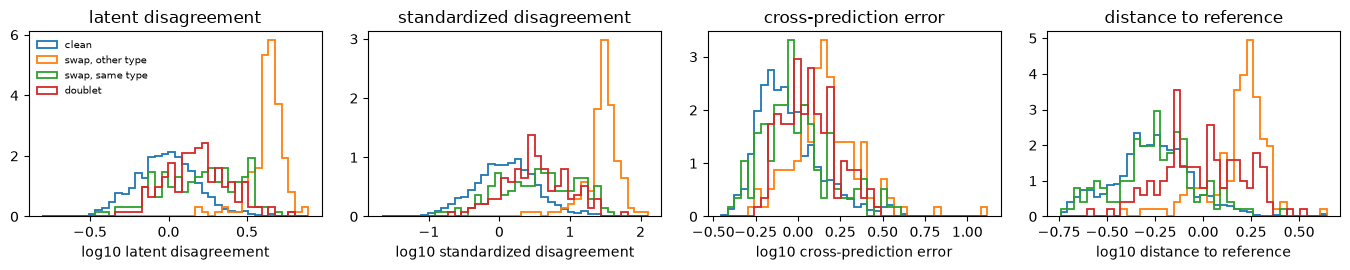

In [7]:
auroc = pd.DataFrame({kind: {name: roc_auc_score(np.r_[np.zeros((kinds == "clean").sum()), np.ones((kinds == kind).sum())],
                                                 np.r_[q_scores[name][kinds == "clean"], q_scores[name][kinds == kind]])
                             for name in q_scores.columns}
                      for kind in ["swap, other type", "swap, same type", "doublet"]})
display(auroc.round(3))

fig, axes = plt.subplots(1, len(q_scores.columns), figsize=(3.4 * len(q_scores.columns), 2.8))
for ax, name in zip(axes, q_scores.columns):
    vals = np.log10(q_scores[name] + 1e-9)
    bins = np.histogram_bin_edges(vals, 40)
    for kind in ["clean", "swap, other type", "swap, same type", "doublet"]:
        ax.hist(vals[kinds == kind], bins=bins, density=True, histtype="step", lw=1.3, label=kind)
    ax.set(xlabel=f"log10 {name}", title=name)
axes[0].legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

Expect disagreement scores to find swaps between cell types and to struggle with swaps within a type
(the two cells are genuinely similar), and expect a doublet, whose two modalities come from the same pair
of cells, to be found by its distance to the reference rather than by disagreement. The table shows
whether that holds here.

## 5. Flagging with a controlled false discovery rate

A raw score has no natural cutoff. **Conformal p-values** give it one: for a barcode with score `s`,
`p = (1 + #{calibration barcodes with score ≥ s}) / (n_calibration + 1)`. If the barcode is clean and
exchangeable with the calibration barcodes, this p-value is valid, and Benjamini–Hochberg applied to
the p-values of many barcodes controls the false discovery rate (Bates et al., 2023, *Annals of
Statistics*). Here the flagging score is `QC_SCORE`, fixed in the parameters cell; choosing the score
after looking at the AUROC table would weaken the guarantee.

In [8]:
def conformal_p(cal, test):
    cal = np.sort(np.asarray(cal))
    n_ge = len(cal) - np.searchsorted(cal, np.asarray(test), side="left")
    return (1 + n_ge) / (len(cal) + 1)


def benjamini_hochberg(p, q):
    p = np.asarray(p)
    order = np.argsort(p)
    passed = p[order] <= q * np.arange(1, len(p) + 1) / len(p)
    k = passed.nonzero()[0].max() + 1 if passed.any() else 0
    flag = np.zeros(len(p), dtype=bool)
    flag[order[:k]] = True
    return flag


rows = {}
for name in q_scores.columns:
    flag = benjamini_hochberg(conformal_p(cal_scores[name], q_scores[name]), FDR_Q)
    row = {"flagged": int(flag.sum()),
           "realized FDR": (flag & (kinds == "clean")).sum() / max(flag.sum(), 1)}
    for kind in ["swap, other type", "swap, same type", "doublet"]:
        row[f"power: {kind}"] = flag[kinds == kind].mean()
    rows[name + (" (chosen)" if name == QC_SCORE else "")] = row
print(f"target FDR {FDR_Q:.0%}; {len(cal_scores)} calibration barcodes; "
      f"{(kinds != 'clean').sum()} corrupted among {len(kinds)} scored")
p_check = conformal_p(cal_scores[QC_SCORE], q_scores[QC_SCORE][kinds == "clean"])
print(f"validity check: {np.mean(p_check <= 0.1):.1%} of clean test barcodes have p <= 0.10 "
      f"(about 10% if they are exchangeable with the calibration barcodes)")
pd.DataFrame(rows).T.astype({"flagged": int}).round(3)

target FDR 10%; 1436 calibration barcodes; 438 corrupted among 1900 scored
validity check: 11.0% of clean test barcodes have p <= 0.10 (about 10% if they are exchangeable with the calibration barcodes)


,flagged,realized FDR,"power: swap, other type","power: swap, same type",power: doublet
latent disagreement,241,0.183,0.959,0.253,0.137
standardized disagreement (chosen),230,0.161,0.938,0.240,0.144
cross-prediction error,0,0.000,0.000,0.000,0.000
distance to reference,0,0.000,0.000,0.000,0.000


The realized FDR counts every flagged clean test barcode as a false discovery. Some of those may be real
problems that were already in the data (the next section looks at them), so the realized FDR can sit
slightly above the target without the procedure failing. The guarantee is for clean barcodes that are
exchangeable with the calibration barcodes, so it does not extend to training cells (the model has fit
them) or to a new sample processed differently.

## 6. What does it flag among real, uncorrupted cells?

The same procedure applied to the clean test barcodes alone, with the chosen score. Flagged barcodes are
compared with the others on sequencing depth and cell type.

In [9]:
clean = kinds == "clean"
p_clean = conformal_p(cal_scores[QC_SCORE], q_scores[QC_SCORE][clean])
flag_clean = benjamini_hochberg(p_clean, FDR_Q)
rna_counts = np.asarray(test_rna_raw.layers["counts"].sum(axis=1)).ravel()
atac_counts = np.asarray(test_atac_raw.layers["counts"].sum(axis=1)).ravel()
summary = pd.DataFrame({"flagged": flag_clean, "cell_type": test_labels,
                        "RNA counts": rna_counts, "ATAC counts": atac_counts})
print(f"{flag_clean.sum()} of {clean.sum()} clean test barcodes flagged at FDR {FDR_Q:.0%}")
display(summary.groupby("flagged")[["RNA counts", "ATAC counts"]].median().round(0))
by_type = summary.groupby("cell_type")["flagged"].agg(["sum", "size", "mean"])
by_type.columns = ["flagged", "cells", "fraction flagged"]
by_type.sort_values("fraction flagged", ascending=False).round(3)

0 of 1462 clean test barcodes flagged at FDR 10%


,RNA counts,ATAC counts
flagged,,
False,3714.0,20037.0


,flagged,cells,fraction flagged
cell_type,,,
CD14 Mono,0,384,0.0
CD16 Mono,0,67,0.0
CD4 Naive,0,208,0.0
CD4 TCM,0,168,0.0
CD4 TEM,0,44,0.0
CD8 Naive,0,204,0.0
CD8 TEM_1,0,49,0.0
CD8 TEM_2,0,48,0.0
HSPC,0,4,0.0


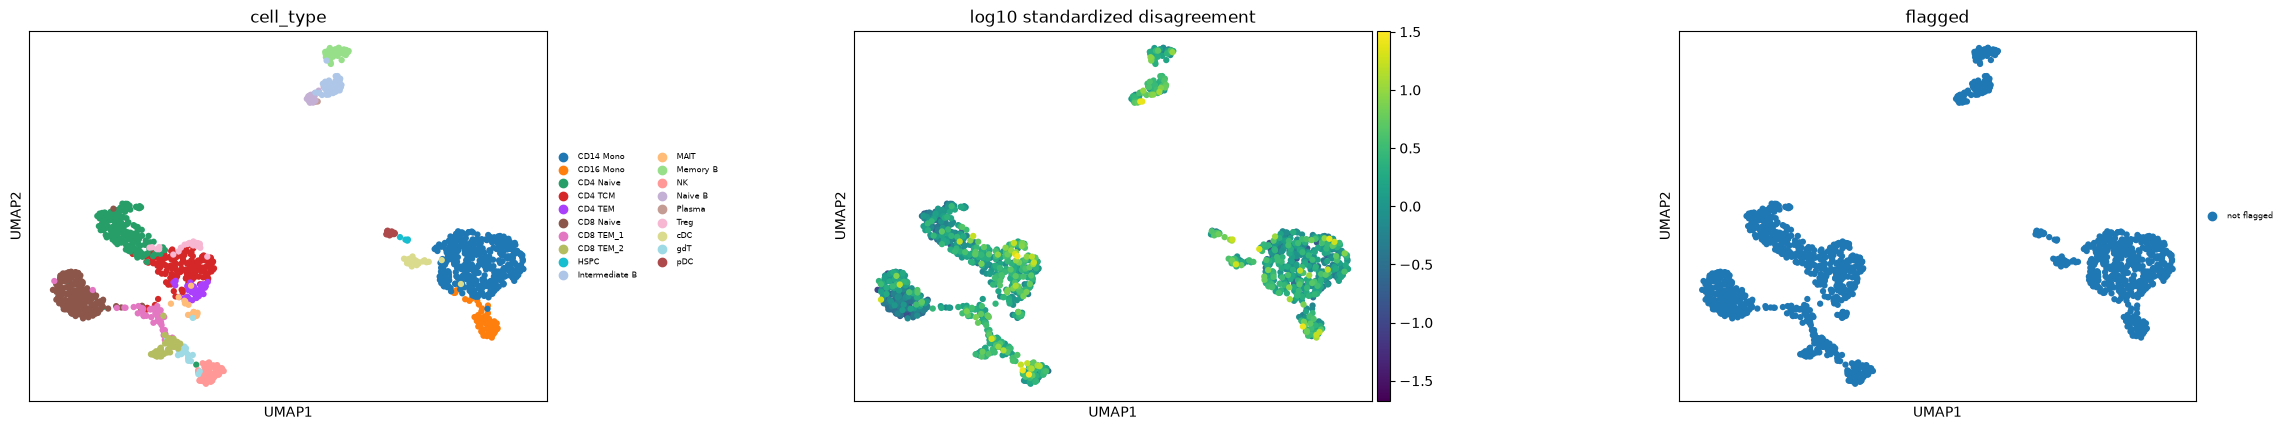

In [10]:
view = ad.AnnData(encode_fused_adata_pair(model, parts["test"], device=device, write_to_adatas=False)["mu"]
                  .astype(np.float32), obs=pd.DataFrame({"cell_type": pd.Categorical(test_labels),
                                                         "flagged": pd.Categorical(np.where(flag_clean, "flagged", "not flagged")),
                                                         f"log10 {QC_SCORE}": np.log10(q_scores[QC_SCORE][clean].to_numpy() + 1e-9)},
                                                        index=parts["test"]["rna"].obs_names))
sc.pp.neighbors(view, n_neighbors=30, use_rep="X")
sc.tl.umap(view, random_state=0)
sc.pl.umap(view, color=["cell_type", f"log10 {QC_SCORE}", "flagged"], wspace=0.45, legend_fontsize=6)

Flagged barcodes concentrated in one cell type can mean either a population the model represents poorly
(check the model's alignment for that type) or a real artifact; unusually high counts point to
multiplets, unusually low counts to damaged cells or empty droplets that passed filtering. None of this
is confirmation, but it tells you which barcodes to inspect first.

## Using this on your own data

- Score barcodes that the model did **not** train on, with calibration barcodes from the same sample
  and processing. To score every barcode of a dataset, use cross-fitting: train two models on halves of
  the data and score each half with the model trained on the other.
- Pick the score before looking at the results, according to the problem you worry about: disagreement
  scores for mis-pairing, distance to the reference for doublets.
- Report flagged barcodes as candidates with their conformal p-values rather than removing them
  silently.